In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/home/mengelsl/MA-bench-framework/outputs/spmv_20260108_154036/spmv_results.csv')

def parse_matrix_info(path):
    """Parses matrix metadata from the file path."""
    filename = path.split('/')[-1].replace('.bin', '')
    parts = filename.split('_')
    density = parts[0]
    n_val = int(parts[1].replace('N', ''))
    return pd.Series([density, n_val, filename])

df[['density', 'N', 'matrix_short']] = df['matrix_path'].apply(parse_matrix_info)

df_avg = df.groupby(['n_cores', 'numa_config', 'N', 'density', 'matrix_short']).median(numeric_only=True).reset_index()

def calculate_hpc_metrics(group):
    base_rows = group[(group['n_cores'] == 1) & (group['numa_config'] == 'OPTIMIZED')]
    if len(base_rows) > 0:
        t1 = base_rows['spmv_avg_s'].values[0]
        group['speedup'] = t1 / group['spmv_avg_s']
        group['efficiency'] = group['speedup'] / group['n_cores']
    else:
        group['speedup'] = np.nan
        group['efficiency'] = np.nan
    return group

df_analysis = df_avg.groupby(['matrix_short']).apply(calculate_hpc_metrics).reset_index(drop=True)
print("Data aggregated by Median. Metrics calculated.")

Data aggregated by Median. Metrics calculated.


/tmp/ipykernel_3892300/3978903772.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_analysis = df_avg.groupby(['matrix_short']).apply(calculate_hpc_metrics).reset_index(drop=True)


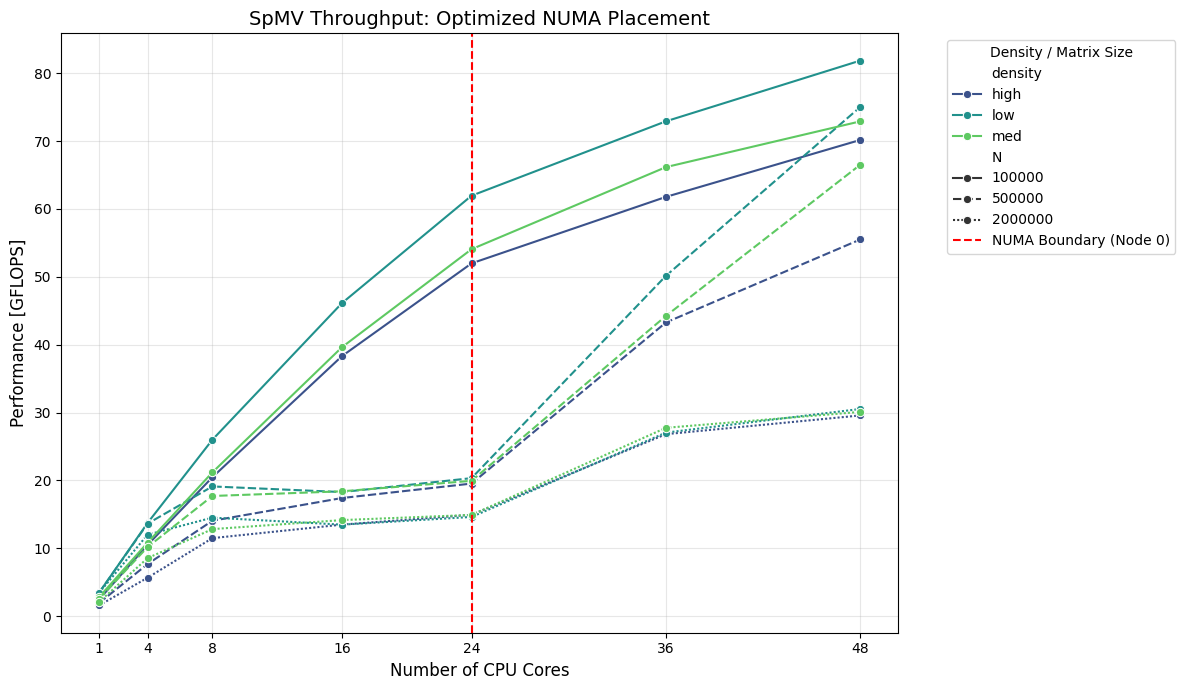

In [2]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_analysis[df_analysis['numa_config'] == 'OPTIMIZED'], 
             x='n_cores', y='gflops', hue='density', style='N', marker='o', palette='viridis')

plt.axvline(x=24, color='red', linestyle='--', label='NUMA Boundary (Node 0)')
plt.title("SpMV Throughput: Optimized NUMA Placement", fontsize=14)
plt.xlabel("Number of CPU Cores", fontsize=12)
plt.ylabel("Performance [GFLOPS]", fontsize=12)
plt.xticks([1, 4, 8, 16, 24, 36, 48])
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(title="Density / Matrix Size", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

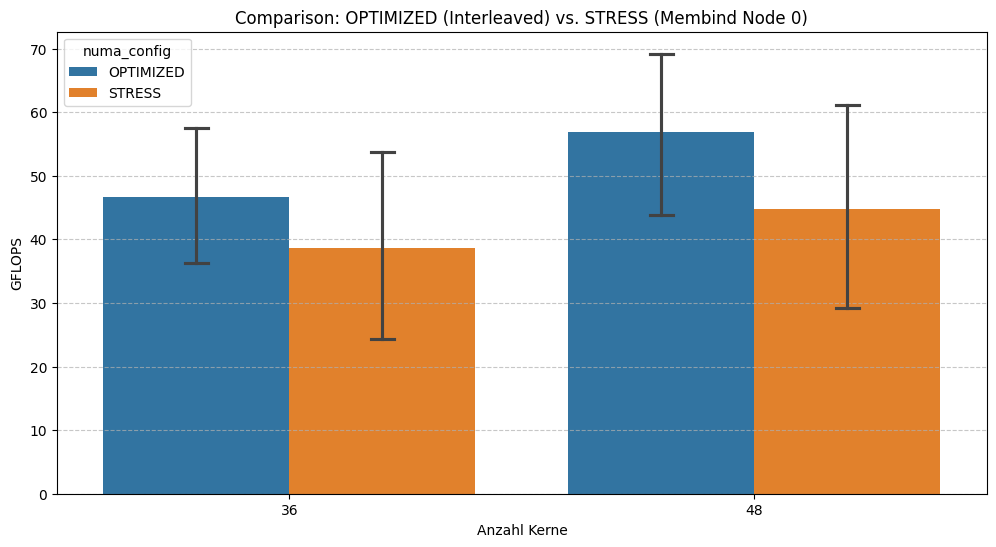

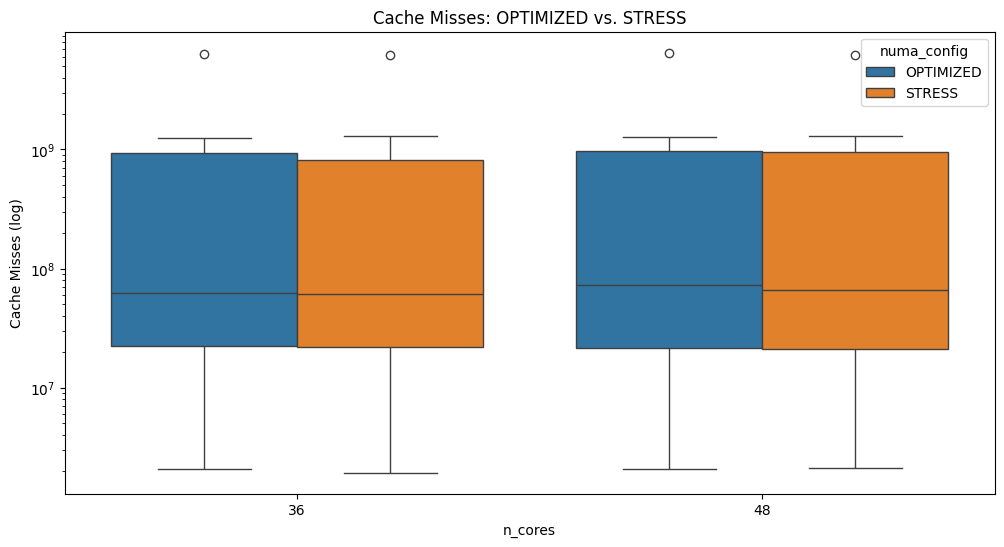

In [3]:
numa_comparison = df_analysis[df_analysis['n_cores'] > 24].copy()

pivot_numa = numa_comparison.pivot_table(
    index=['matrix_short', 'n_cores'], 
    columns='numa_config', 
    values='gflops'
).reset_index()

if 'STRESS' in pivot_numa.columns:
    pivot_numa['penalty_pct'] = (1 - (pivot_numa['STRESS'] / pivot_numa['OPTIMIZED'])) * 100

plt.figure(figsize=(12, 6))
sns.barplot(
    data=numa_comparison, 
    x='n_cores', 
    y='gflops', 
    hue='numa_config',
    capsize=.1
)
plt.title('Comparison: OPTIMIZED (Interleaved) vs. STRESS (Membind Node 0)')
plt.ylabel('GFLOPS')
plt.xlabel('Anzahl Kerne')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=numa_comparison, 
    x='n_cores', 
    y='perf_cache_misses', 
    hue='numa_config'
)
plt.title('Cache Misses: OPTIMIZED vs. STRESS')
plt.yscale('log') 
plt.ylabel('Cache Misses (log)')
plt.show()